# Session 6 demo — ECG and EEG as physiological time-series data

This companion demonstration for [Session 6: Healthcare Data Ecosystem](session-06-data-ecosystem.md) shows what waveform data looks like when loaded into Python. It uses **deterministic synthetic recordings**: the traces, labels, and model results are invented solely for teaching. They are not patient data, clinical evidence, or a diagnostic system.

## Learning objectives

After this demonstration, you should be able to:

- represent a sampled ECG or EEG recording as an array and attach its metadata;
- plot a short time window using a sampling rate and physical units;
- compare frequency content using a simple power spectrum; and
- build and evaluate a small model for a clearly limited, synthetic signal-quality task.

**Prerequisites:** introductory Python, arrays/tables, and the idea of a train/test split.

## 1. Clinical purpose, computational task, and safeguards

An **electrocardiogram (ECG)** records electrical activity associated with the heart; an **electroencephalogram (EEG)** records electrical activity associated with the brain. In both cases, a stored file contains numerical samples over time, not a screenshot of a waveform. Real recordings also need channel labels, units, sampling rate, calibration, acquisition time, and often annotations.

For a safe classroom task, our target is **recording-quality flag** (`artifact_present`), not a disease label. The intended user is a fictional data analyst deciding whether a recording needs review before analysis. The model is deliberately simple and must not be used for clinical decisions.

In [1]:
# tempfile gives this demonstration a disposable folder: it leaves no generated
# recordings in the repository after the notebook finishes.
import tempfile
from pathlib import Path

# NumPy holds and transforms the waveform arrays; pandas holds recording-level
# metadata; matplotlib draws plots; scikit-learn supplies the ML demonstration.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GroupShuffleSplit

# A fixed seed makes every rerun create exactly the same fictional recordings.
# It is useful for teaching and debugging, but does not make data realistic.
RNG = np.random.default_rng(20260910)
# Apply a readable style to all plots made below.
plt.style.use("seaborn-v0_8-whitegrid")

## 2. Generate and save miniature recordings

We create one ECG-like channel (`Lead II`, millivolts) and one EEG-like channel (`C3-A2`, microvolts). These are visual approximations, not a physiological simulator. Each archive has an array with shape **recordings × samples**, a sampling rate, units, channel name, and recording IDs. Saving and reloading `.npz` archives mirrors the array-plus-metadata workflow, but real ECG datasets commonly use WFDB and EEG datasets often use EDF/EDF+.

### What do electrode, lead, and channel mean?

Think of an **electrode** as a small sensor sticker on the body. A **lead** is a particular electrical *view* created by comparing electrodes. A **channel** is one stream of numbers that the device saves and draws as one waveform. ECG discussions commonly say *lead*; EEG discussions commonly say *channel*.

- **`Lead II` (ECG):** a standard view that compares the right-arm electrode with the left-leg electrode. It often shows a typical heartbeat clearly. Its amplitude is usually recorded in **millivolts (mV)**, where 1 mV = 0.001 volt.
- **`C3-A2` (EEG):** one EEG channel that compares the `C3` scalp electrode (a left-central location) with `A2`, a reference near the right ear/mastoid region. It is a difference between two electrode measurements, not a direct measurement of brain activity at C3 alone.

Real recordings can use different references or montages, so always read the channel labels and recording metadata before interpreting a trace.

In [ ]:
def gaussian(t, centre, width, amplitude):
    """Return a bell-shaped bump evaluated at every time in array t.

    centre is the bump's time in seconds, width controls its spread, and
    amplitude controls its height. We reuse these bumps to draw simple
    waveform components; this is not a physiological model.
    """
    return amplitude * np.exp(-0.5 * ((t - centre) / width) ** 2)

def synthetic_ecg(t, heart_rate, artifact):
    """A visual teaching approximation of repeated P-QRS-T complexes."""
    # Convert beats per minute to seconds per beat: 60/75 = 0.8 s, for example.
    beat_period = 60 / heart_rate
    # Start with one zero-valued sample for every time point.
    signal = np.zeros_like(t)
    # Add a simplified P-QRS-T-shaped pattern at the start of each fictional beat.
    for beat_start in np.arange(0.4, t[-1] + beat_period, beat_period):
        signal += gaussian(t, beat_start - 0.16, 0.025, 0.12)  # P-like
        signal += gaussian(t, beat_start - 0.025, 0.010, -0.15) # Q-like
        signal += gaussian(t, beat_start, 0.012, 1.00)          # R-like
        signal += gaussian(t, beat_start + 0.025, 0.012, -0.25) # S-like
        signal += gaussian(t, beat_start + 0.24, 0.060, 0.28)   # T-like
    # Add small random noise to every sample to avoid a perfectly smooth trace.
    signal += 0.025 * RNG.normal(size=t.size)
    if artifact:
        # Plant two easy-to-see data-quality problems: a 50-Hz oscillation and
        # a brief large bump. These artificial patterns define our later label.
        signal += 0.18 * np.sin(2 * np.pi * 50 * t)  # simulated mains interference
        signal += 0.35 * gaussian(t, 2.7, 0.09, 1)   # simulated motion transient
    return signal

def synthetic_eeg(t, artifact):
    """A visual teaching approximation with alpha-like activity and noise."""
    # Give each recording a different-sized 10-Hz alpha-like oscillation.
    alpha_amplitude = RNG.uniform(14, 28)
    # Combine alpha-like 10-Hz activity, a slower 4-Hz component, and random noise.
    # The random phase shifts where the oscillation begins in each recording.
    signal = (alpha_amplitude * np.sin(2 * np.pi * 10 * t + RNG.uniform(0, 2*np.pi))
              + 8 * np.sin(2 * np.pi * 4 * t)
              + 4 * RNG.normal(size=t.size))
    if artifact:
        # Plant high-frequency interference and a short transient, analogous to
        # the deliberately artificial ECG artifacts above.
        signal += 22 * np.sin(2 * np.pi * 45 * t)
        signal += 55 * gaussian(t, 3.2, 0.12, 1)
    return signal

# Sample 250 times each second for 5 seconds, yielding 1,250 samples/recording.
sampling_rate_hz = 250
duration_s = 5
# arange makes 0, 1/250, 2/250, ... seconds: the time coordinate for each sample.
time_s = np.arange(0, duration_s, 1 / sampling_rate_hz)
# Make a small, fast-to-run teaching collection for each modality.
n_recordings_per_modality = 40

# records holds the waveform arrays; rows holds one metadata dictionary per recording.
records, rows = [], []
for modality in ["ECG", "EEG"]:
    for recording_number in range(n_recordings_per_modality):
        # Alternate labels so each modality has 20 clean and 20 artifact examples.
        # This label is planted by us, rather than being a clinical annotation.
        artifact_present = recording_number % 2 == 0
        # A recording ID identifies this whole waveform; it is not a patient ID.
        recording_id = f"{modality}-{recording_number:03d}"
        signal = (synthetic_ecg(time_s, RNG.uniform(58, 92), artifact_present)
                  if modality == "ECG" else synthetic_eeg(time_s, artifact_present))
        # Keep the signal in memory and separately create its recording-level metadata.
        records.append((modality, recording_id, signal))
        rows.append({"recording_id": recording_id, "modality": modality,
                     "channel": "Lead II" if modality == "ECG" else "C3-A2",
                     "unit": "mV" if modality == "ECG" else "µV",
                     "sampling_rate_hz": sampling_rate_hz,
                     "duration_s": duration_s,
                     "artifact_present": int(artifact_present)})

# Convert the list of dictionaries to a familiar one-row-per-recording table.
metadata = pd.DataFrame(rows)
# The context manager removes this folder at the end of the indented block.
with tempfile.TemporaryDirectory() as temporary_directory:
    data_directory = Path(temporary_directory)
    # Save one compact NumPy archive per modality, like a supplied signal file.
    for modality in ["ECG", "EEG"]:
        # Select only recordings of the current modality.
        subset = [(recording_id, signal) for m, recording_id, signal in records if m == modality]
        # .npz is compressed numpy data file format, which is convenient for storing multiple arrays.
        # Here we are storing the signals, recording IDs and sampling rate in a single .npz file for each modality.
        np.savez(data_directory / f"synthetic_{modality.lower()}.npz",
                 # stack makes a 2D array: rows are recordings, columns are time samples.
                 signals=np.stack([signal for _, signal in subset]),
                 recording_ids=np.array([recording_id for recording_id, _ in subset]),
                 sampling_rate_hz=sampling_rate_hz)
    # Keep descriptive fields outside the waveform array, in a CSV table.
    metadata.to_csv(data_directory / "recording_metadata.csv", index=False)

    # Load the files exactly as an analysis notebook would load supplied data.
    loaded_metadata = pd.read_csv(data_directory / "recording_metadata.csv")
    # Copy each archive's arrays into memory before the temporary folder disappears.
    with np.load(data_directory / "synthetic_ecg.npz") as archive:
        ecg_archive = {key: archive[key] for key in archive.files}
    with np.load(data_directory / "synthetic_eeg.npz") as archive:
        eeg_archive = {key: archive[key] for key in archive.files}

loaded_metadata.head(), ecg_archive["signals"].shape, eeg_archive["signals"].shape

(  recording_id modality  channel unit  sampling_rate_hz  duration_s  \
 0      ECG-000      ECG  Lead II   mV               250           5   
 1      ECG-001      ECG  Lead II   mV               250           5   
 2      ECG-002      ECG  Lead II   mV               250           5   
 3      ECG-003      ECG  Lead II   mV               250           5   
 4      ECG-004      ECG  Lead II   mV               250           5   
 
    artifact_present  
 0                 1  
 1                 0  
 2                 1  
 3                 0  
 4                 1  ,
 (40, 1250),
 (40, 1250))

The shape `(40, 1250)` means 40 recordings and 1,250 samples each: `250 samples/second × 5 seconds`. The row table describes recordings; the waveform archive contains samples. Do not treat the 1,250 samples as 1,250 independent patients.

### One lead here; many leads in a standard ECG

The synthetic ECG in this notebook has only one channel, **Lead II**, so its plot has one waveform. A standard 12-lead ECG has 12 synchronized waveform traces: each lead observes the same heartbeats from a different electrical direction, so their shapes and amplitudes can differ. The traces are not 12 separate heartbeats; they are 12 views of the same recording. Software may show them as stacked plots or in a standard 12-lead layout.

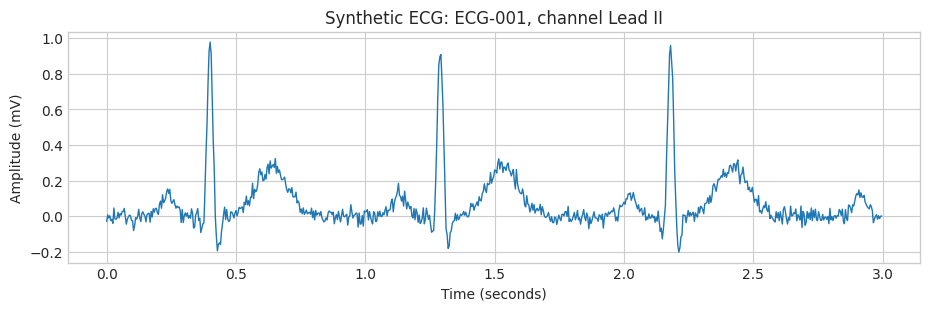

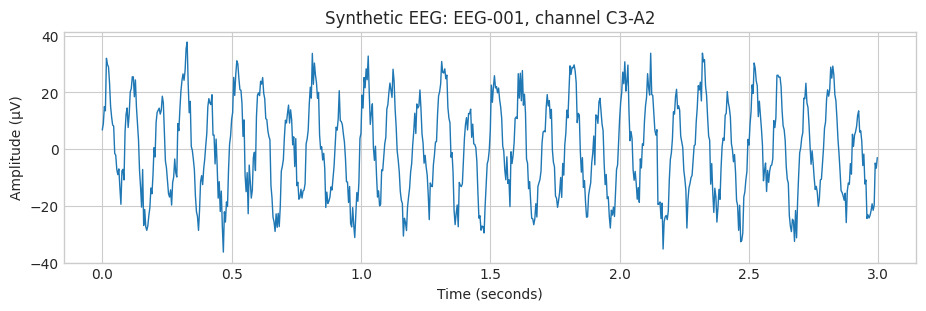

In [3]:
def plot_recording(archive, metadata_table, modality, row_index=1, seconds_to_show=3):
    """Plot a short segment of one recording, using its metadata for labels."""
    # Select one row from the 2D waveform array; this returns a 1D sample sequence.
    signal = archive["signals"][row_index]
    # Use the matching ID to locate channel name, unit, and sampling-rate metadata.
    recording_id = archive["recording_ids"][row_index]
    details = metadata_table.loc[metadata_table.recording_id == recording_id].iloc[0]
    # Convert the requested duration into a number of samples: seconds × samples/second.
    sample_count = int(seconds_to_show * details.sampling_rate_hz)
    # Convert sample indices (0, 1, 2, ...) back into time in seconds.
    time_axis = np.arange(sample_count) / details.sampling_rate_hz
    plt.figure(figsize=(11, 3))
    plt.plot(time_axis, signal[:sample_count], linewidth=1)
    plt.xlabel("Time (seconds)")
    plt.ylabel(f"Amplitude ({details.unit})")
    plt.title(f"Synthetic {modality}: {recording_id}, channel {details.channel}")
    plt.show()

# Plot the second recording (index 1) from each archive for visual comparison.
plot_recording(ecg_archive, loaded_metadata, "ECG")
plot_recording(eeg_archive, loaded_metadata, "EEG")

## 3. Look in the frequency domain

A waveform is usually first viewed against time. A **power spectrum** instead shows how much signal energy occurs at different frequencies. Here we use a fast Fourier transform (FFT) for a simple visual comparison. Frequency analysis does not by itself establish a clinical finding: in real data, filtering choices, electrode contact, reference/montage, and artifacts all matter.

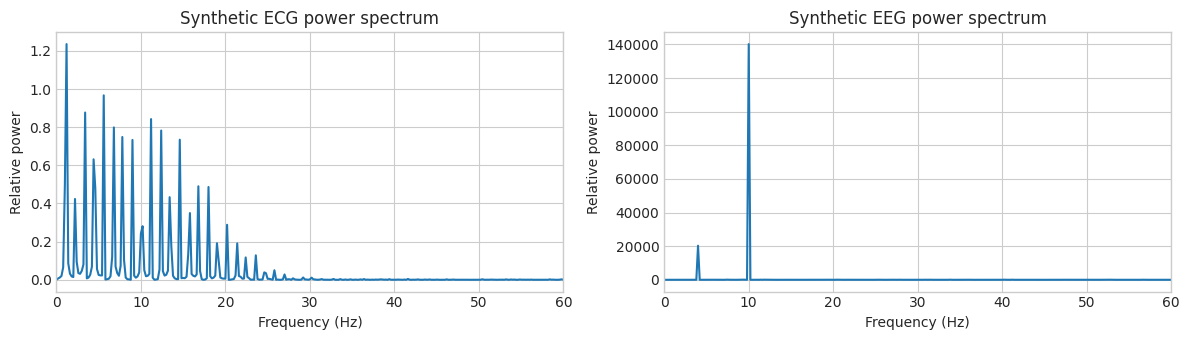

In [5]:
def power_spectrum(signal, sampling_rate):
    """Return non-negative frequencies and a simple relative-power estimate."""
    # Remove the average amplitude so the constant baseline does not dominate 0 Hz.
    centred = signal - signal.mean()
    # rfftfreq gives the frequency corresponding to each FFT output value.
    # It is sufficient because a real-valued signal has mirrored negative frequencies.
    frequencies = np.fft.rfftfreq(centred.size, d=1 / sampling_rate)
    # rfft changes the time sequence into frequency components. Squared magnitude is
    # a simple power-like quantity, normalized here by number of samples.
    power = np.abs(np.fft.rfft(centred)) ** 2 / centred.size
    return frequencies, power

# Make one axis for each modality so their frequency patterns can be compared.
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=False)
for axis, archive, modality in zip(axes, [ecg_archive, eeg_archive], ["ECG", "EEG"]):
    # Analyze the same second recording that was used in the waveform plots.
    frequencies, power = power_spectrum(archive["signals"][1], sampling_rate_hz)
    axis.plot(frequencies, power)
    axis.set(xlim=(0, 60), xlabel="Frequency (Hz)", ylabel="Relative power",
             title=f"Synthetic {modality} power spectrum")
# Adjust spacing so axis labels and titles do not overlap.
plt.tight_layout()

## 4. From recordings to features

A model needs a defined unit of analysis. Below, **one row means one whole recording**. We extract intentionally simple features: standard deviation, peak-to-peak range, and the fraction of power above 30 Hz. These are not a validated signal-quality pipeline; they make the transformation from a waveform array to a modeling table visible.

In [6]:
def signal_features(signal, sampling_rate):
    """Summarize one waveform as three numeric features for the toy model."""
    # Reuse the spectrum function rather than treating raw samples as model rows.
    frequencies, power = power_spectrum(signal, sampling_rate)
    # Boolean masks select frequency bins within each range, then sum their power.
    total_power = power[(frequencies >= 0.5) & (frequencies <= 100)].sum()
    high_frequency_power = power[(frequencies >= 30) & (frequencies <= 60)].sum()
    return {
        # Standard deviation describes typical variation around the mean.
        "amplitude_sd": signal.std(),
        # Peak-to-peak is maximum amplitude minus minimum amplitude.
        "peak_to_peak": np.ptp(signal),
        # A ratio makes high-frequency power comparable across overall amplitudes.
        "high_frequency_fraction": high_frequency_power / total_power,
    }

# Create exactly one feature-table row per whole recording.
feature_rows = []
for modality, recording_id, signal in records:
    feature_rows.append({"recording_id": recording_id, **signal_features(signal, sampling_rate_hz)})
# Join features to metadata by recording ID. one_to_one checks that no recording
# was unexpectedly duplicated during the merge.
features = loaded_metadata.merge(pd.DataFrame(feature_rows), on="recording_id", validate="one_to_one")
features.head()

,recording_id,modality,channel,unit,sampling_rate_hz,duration_s,artifact_present,amplitude_sd,peak_to_peak,high_frequency_fraction
0,ECG-000,ECG,Lead II,mV,250,5,1,0.212892,1.491995,0.371290
1,ECG-001,ECG,Lead II,mV,250,5,0,0.160009,1.179567,0.007762
2,ECG-002,ECG,Lead II,mV,250,5,1,0.204164,1.456883,0.408617
3,ECG-003,ECG,Lead II,mV,250,5,0,0.160486,1.211047,0.006643
4,ECG-004,ECG,Lead II,mV,250,5,1,0.222785,1.441940,0.338390


## 5. A small, honest ML demonstration

We predict the **synthetic artifact flag** from the three features. The split is by `recording_id`, so no samples from a recording can appear in both training and test data. This is essential for real physiological data: overlapping windows, repeated recordings, or multiple visits from the same person must not silently leak into the test set.

Because the artifact pattern was deliberately planted, high performance here would only show that the code can recover our simulation. It does not estimate performance on hospital ECGs, EEGs, devices, people, or clinical tasks.

                     precision    recall  f1-score   support

no planted artifact       1.00      1.00      1.00         9
   planted artifact       1.00      1.00      1.00        11

           accuracy                           1.00        20
          macro avg       1.00      1.00      1.00        20
       weighted avg       1.00      1.00      1.00        20



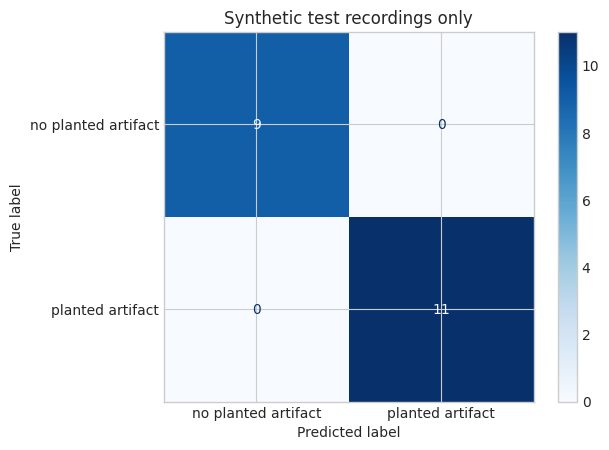

In [7]:
# These three columns are inputs. artifact_present is kept separate as the target.
feature_columns = ["amplitude_sd", "peak_to_peak", "high_frequency_fraction"]
# Reserve 25% of complete recordings for testing. In a windowed real dataset,
# grouping by recording/patient prevents related windows leaking across the split.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=7)
train_index, test_index = next(splitter.split(features, groups=features["recording_id"]))
train_data, test_data = features.iloc[train_index], features.iloc[test_index]

# A random forest combines many decision trees. Fixed settings make this demo repeatable.
model = RandomForestClassifier(n_estimators=200, random_state=7, min_samples_leaf=2)
# Fit only on the training recordings and their planted labels.
model.fit(train_data[feature_columns], train_data["artifact_present"])
# Predict labels for held-out recordings that the model did not see during fitting.
predicted_flag = model.predict(test_data[feature_columns])

# Compare known synthetic labels with predictions using precision, recall, and F1.
print(classification_report(test_data["artifact_present"], predicted_flag,
                            target_names=["no planted artifact", "planted artifact"], zero_division=0))
# The confusion matrix shows counts of correct and incorrect predictions by class.
ConfusionMatrixDisplay.from_predictions(test_data["artifact_present"], predicted_flag,
                                      display_labels=["no planted artifact", "planted artifact"],
                                      cmap="Blues")
plt.title("Synthetic test recordings only")
plt.show()

## 6. Interpret before claiming success

Questions to discuss:

1. What do the array dimensions mean? Which axis is time, and which is recording?
2. Why are `mV` and `µV` not interchangeable, even though both are voltages?
3. Why would a random split of overlapping 5-second windows produce an optimistic test result?
4. What metadata and independently labeled recordings would be needed before a real signal-quality model could be evaluated?
5. If the task were clinical instead of quality review, what would its intended user, decision time, target label, and safety checks need to be?

## Further reading

- [WFDB documentation](https://physionet.org/physiotools/wpg/wpg_39.htm) for common physiological-waveform files.
- [EDF specification](https://www.edfplus.info/specs/edf.html) for EEG and other physiological recordings.
- The physiological-signals section of the companion [Session 6 notes](session-06-data-ecosystem.md#5-physiological-signals).